sample: 100%|██████████| 1500/1500 [02:21<00:00, 10.63it/s, 9 steps of size 3.25e-03. acc. prob=0.71]   


Empirical risk: 0.084
Confidence term: 0.633
KL-Divergence: 638.055
Pac-Bayes Bound: 0.717
MSE: 0.040
Time taken: 141.493
elpd_waic
103.94
p_waic
8.69
waic_se
0.02
elpd_loo
103.90
p_loo
8.73
loo_se
0.02
avg_rhat
NaN
avg_ess
36.38
total_params
197


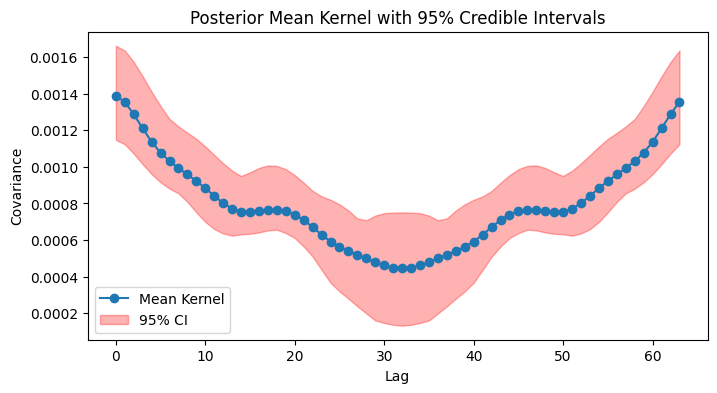

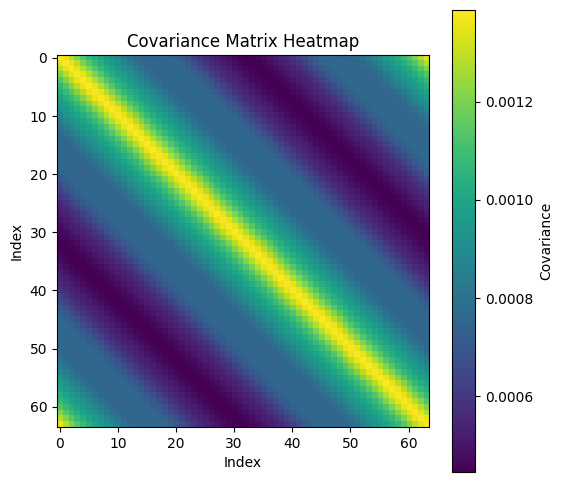

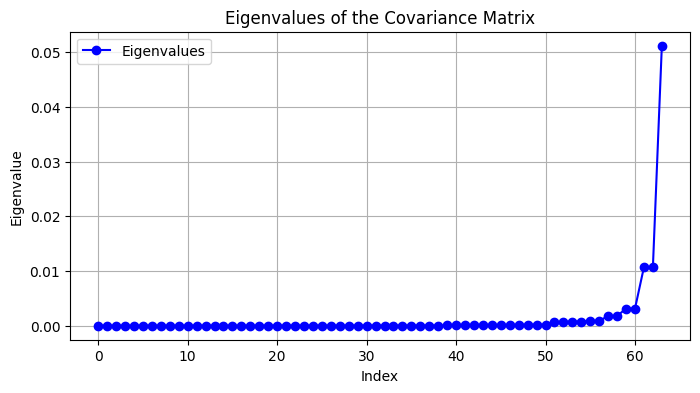

Minimum eigenvalue: 5.1930056e-07
Cholesky decomposition succeeded. The matrix is positive semidefinite.


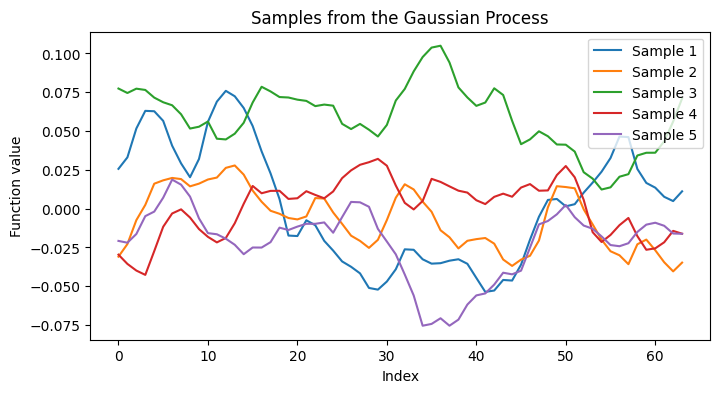

In [58]:
import jax
import jax.random as jr
import numpy as np 
import time 
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from quantbayes import bnn
from quantbayes.fake_data import generate_regression_data 
from quantbayes.bnn.utils import BayesianAnalysis, evaluate_mcmc

@jax.custom_jvp
def spectral_circulant_matmul(x: jnp.ndarray, fft_full: jnp.ndarray) -> jnp.ndarray:
    """
    Multiply an input x by a circulant matrix defined in the frequency domain.
    Instead of using fft_full directly, we use the PSD = |fft_full|^2.
    """
    padded_dim = fft_full.shape[0]
    single_example = x.ndim == 1
    if single_example:
        x = x[None, :]
    d_in = x.shape[-1]
    if d_in < padded_dim:
        pad_len = padded_dim - d_in
        x_pad = jnp.pad(x, ((0, 0), (0, pad_len)))
    elif d_in > padded_dim:
        x_pad = x[..., :padded_dim]
    else:
        x_pad = x

    # Compute the FFT of the padded input.
    X_fft = jnp.fft.fft(x_pad, axis=-1)
    # Compute the PSD = |fft_full|^2 (ensuring nonnegativity).
    PSD = jnp.abs(fft_full)**2
    # Multiply in the Fourier domain.
    y_fft = X_fft * PSD[None, :]
    # Inverse FFT gives the time-domain output.
    y = jnp.fft.ifft(y_fft, axis=-1).real
    if single_example:
        return y[0]
    return y

@spectral_circulant_matmul.defjvp
def spectral_circulant_matmul_jvp(primals, tangents):
    x, fft_full = primals
    dx, dfft = tangents
    padded_dim = fft_full.shape[0]

    single_example = x.ndim == 1
    if single_example:
        x = x[None, :]
        if dx is not None:
            dx = dx[None, :]
    d_in = x.shape[-1]
    if d_in < padded_dim:
        pad_len = padded_dim - d_in
        x_pad = jnp.pad(x, ((0, 0), (0, pad_len)))
        dx_pad = jnp.pad(dx, ((0, 0), (0, pad_len))) if dx is not None else None
    elif d_in > padded_dim:
        x_pad = x[..., :padded_dim]
        dx_pad = dx[..., :padded_dim] if dx is not None else None
    else:
        x_pad = x
        dx_pad = dx

    # Compute FFT of the input.
    X_fft = jnp.fft.fft(x_pad, axis=-1)
    # Compute the PSD from fft_full.
    PSD = jnp.abs(fft_full)**2
    # Forward pass: Y = IFFT( X_fft * PSD )
    primal_y_fft = X_fft * PSD[None, :]
    primal_y = jnp.fft.ifft(primal_y_fft, axis=-1).real

    # Tangent for the input FFT:
    if dx_pad is None:
        dX_fft = 0.0
    else:
        dX_fft = jnp.fft.fft(dx_pad, axis=-1)
    # Tangent for the PSD:
    if dfft is None:
        term2 = 0.0
    else:
        # Derivative of PSD = |fft_full|^2:
        # dPSD = fft_full * conj(dfft) + dfft * conj(fft_full)
        dPSD = fft_full * jnp.conjugate(dfft) + dfft * jnp.conjugate(fft_full)
        term2 = X_fft * dPSD[None, :]
    dY_fft = dX_fft * PSD[None, :] + term2
    dY = jnp.fft.ifft(dY_fft, axis=-1).real

    if single_example:
        return primal_y[0], dY[0]
    return primal_y, dY

# ---------------------
class SpectralCircGP:
    """
    NumPyro-based 'spectral' circulant layer with a custom JVP.

    This layer implements a spectral construction of a Gaussian Process (GP) kernel using
    circulant matrices and a half-spectrum representation. It leverages a hyperprior on the 
    frequency scaling exponent α and allows for either a simple bias term or a latent function 
    sampled from a CirculantNormal distribution as an additive term.

    The kernel is constructed via the power spectral density (PSD):
        k(t) = IFFT( |S(ω)|² )
    where the Fourier coefficients S(ω) are given by:
        S(ω) = a(ω) + i * b(ω).

    The coefficients are sampled as follows:
        scale = 1 / sqrt(1 + α²)
        α ~ HalfNormal(1)
        a(ω) ~ Normal(0, scale)
        b(ω) ~ Normal(0, scale)

    To ensure that the resulting kernel is real-valued, we enforce Hermitian symmetry:
        - Set the DC component (s[0]) to be real (i.e., its imaginary part is 0).
        - If n is even, enforce the Nyquist frequency s[n/2] to be real.
        - Construct the full spectrum by concatenating the half-spectrum with its conjugate:
            s = concat(s[:-1], nyquist, conjugate(s[1:-1])[::-1])
            
    The PSD is then computed as:
        PSD = |S(ω)|² = a(ω)² + b(ω)²

    By Bochner's theorem, the inverse FFT of a nonnegative PSD yields a valid, 
    positive semidefinite stationary kernel:
        conv_row = IFFT(PSD).real

    Finally, the layer transforms an input X via FFT-based multiplication with the PSD:
        ŷ = IFFT( FFT(X) * PSD ).real + (bias or f)
    where the additive term is either:
        - A simple bias sampled as: bias ~ Normal(0,1), or
        - A latent function f sampled from a CirculantNormal distribution:
            f ~ CirculantNormal(0, conv_row)

    This implementation guarantees that every realization of the kernel is nonnegative,
    thereby ensuring a valid GP covariance.
    """

    def __init__(
        self,
        in_features: int,
        padded_dim: int = None,
        alpha: float = None, 
        alpha_prior=dist.HalfNormal(1),
        K: int = None,
        name: str = "spectral_circ_jvp",
        prior_fn=None,  
        use_bias: bool = True,  
    ):
        """
        :param in_features: input dimension.
        :param padded_dim: if not None, zero-pad/truncate to that dimension.
        :param alpha: fixed value for exponent α; if None, a hyperprior is used.
        :param alpha_prior: Custom prior distribution on alpha (default: HalfNormal(1)).
        :param K: number of active frequencies to keep.
        :param name: base name for NumPyro samples.
        :param prior_fn: a callable scale -> distribution (default: Normal(0, scale)).
        :param use_bias: if True, add a simple bias; if False, add a latent function sampled
                         from a CirculantNormal with covariance given by the PSD kernel.
        """
        self.in_features = in_features
        self.padded_dim = padded_dim if padded_dim is not None else in_features
        self.alpha = alpha
        self.alpha_prior = alpha_prior
        self.name = name
        self.use_bias = use_bias

        self.k_half = (self.padded_dim // 2) + 1
        if (K is None) or (K > self.k_half):
            K = self.k_half
        self.K = K

        if prior_fn is None:
            self.prior_fn = lambda scale: dist.Normal(0.0, scale)
        else:
            self.prior_fn = prior_fn

        self._last_fft_full = None

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # Sample alpha if not fixed.
        if self.alpha is None:
            alpha = numpyro.sample(f"{self.name}_alpha", self.alpha_prior)
        else:
            alpha = self.alpha

        freq_idx = jnp.arange(self.k_half)
        prior_std = 1.0 / jnp.sqrt(1.0 + freq_idx**alpha)

        active_idx = jnp.arange(self.K)
        active_real = numpyro.sample(
            f"{self.name}_real",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1),
        )
        active_imag = numpyro.sample(
            f"{self.name}_imag",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1),
        )

        full_real = jnp.zeros((self.k_half,))
        full_imag = jnp.zeros((self.k_half,))
        full_real = full_real.at[active_idx].set(active_real)
        full_imag = full_imag.at[active_idx].set(active_imag)

        full_imag = full_imag.at[0].set(0.0)
        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            full_imag = full_imag.at[-1].set(0.0)

        half_complex = full_real + 1j * full_imag

        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            nyquist = half_complex[-1].real[None]
            fft_full = jnp.concatenate(
                [half_complex[:-1], nyquist, jnp.conjugate(half_complex[1:-1])[::-1]]
            )
        else:
            fft_full = jnp.concatenate(
                [half_complex, jnp.conjugate(half_complex[1:])[::-1]]
            )

        self._last_fft_full = jax.lax.stop_gradient(fft_full)

        # PSD = |S(ω)|^2
        # Bochners Theorem: k(t) = IFFT(PSD) 
        cov_row = jnp.fft.ifft(jnp.abs(fft_full)**2).real

        if self.use_bias:
            additional = numpyro.sample(
                f"{self.name}_bias_spectral",
                dist.Normal(0.0, 1.0).expand([self.padded_dim]).to_event(1),
            )
        else:
            circ_dist = dist.CirculantNormal(
                loc=jnp.zeros(self.padded_dim), covariance_row=cov_row
            )
            additional = numpyro.sample(f"{self.name}_latent_function", circ_dist)

        transformed = spectral_circulant_matmul(x, fft_full)

        if transformed.ndim == 2:
            additional = additional[None, :]
        else:
            additional = additional
        return transformed + additional

    def get_kernel(self) -> jnp.ndarray:
        """
        Returns the covariance kernel (impulse response) computed from the PSD,
        without any additional bias/latent function.
        """
        impulse = jnp.zeros(self.padded_dim)
        impulse = impulse.at[0].set(1.0)
        fft_full = self.get_fourier_coeffs()
        X_fft = jnp.fft.fft(impulse)
        PSD = jnp.abs(fft_full)**2
        kernel_fft = X_fft * PSD
        kernel = jnp.fft.ifft(kernel_fft).real
        return kernel

    def get_fourier_coeffs(self) -> jnp.ndarray:
        if self._last_fft_full is None:
            raise ValueError("No Fourier coefficients available; call the layer first.")
        return self._last_fft_full



df = generate_regression_data(n_continuous=64)
X, y = df.drop("target", axis=1), df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

class Test(bnn.Module):
    def __init__(self):
        super().__init__()
        self.fft_layer = SpectralCircGP(64, use_bias=False)
    def __call__(self, X, y=None):
        N, D = X.shape
        X = self.fft_layer(X)
        X = jax.nn.tanh(X)
        X = bnn.Linear(D, 1)(X)
        mu = X.squeeze()
        sigma = numpyro.sample("sigma", dist.Exponential(1.0))
        with numpyro.plate("data", N):
            numpyro.sample("logits", dist.Normal(mu, sigma), obs=y)

key = jr.key(0)
model = Test()
model.compile(num_warmup=500, num_samples=1000)
tak = time.time()
model.fit(X_train, y_train, key)
tik = time.time()
preds = model.predict(X_test, key)
mean_preds = preds.mean(axis=0)
mse = mean_squared_error(np.array(y_test), np.array(mean_preds))
diagnostics = evaluate_mcmc(model)
bound = BayesianAnalysis(len(X_train), inference_type="mcmc", posterior_samples=model.get_samples)
bound.compute_pac_bayesian_bound(preds, y_test)
print(f"MSE: {mse:.3f}")
print(f"Time taken: {tik-tak:.3f}")
for key, value in diagnostics.items():
    print(key)
    print(value)



from numpyro import handlers
import jax.random as jr
import numpy as np
from scipy.linalg import toeplitz, cholesky, LinAlgError

def get_kernel_for_params(model, X, param_dict, rng_key=jr.PRNGKey(0)):
    """
    Substitute a concrete parameter set into the model and run one forward pass
    with a provided rng_key so that the sample sites receive valid keys.
    This triggers model.fft_layer to store its Fourier coefficients, from which
    we retrieve the kernel.
    """
    with handlers.seed(rng_seed=rng_key):
        with handlers.substitute(data=param_dict):
            _ = model(X)  # Run forward pass to set up Fourier coefficients.
    kernel = model.fft_layer.get_kernel()
    return jax.device_get(kernel)

# Example: Collect kernel samples from posterior.
n_samples = 50  # number of posterior draws to analyze.
kernel_samples = []
posterior_samples = model.get_samples
for i in range(n_samples):
    sample_param_dict = {k: v[i] for k, v in posterior_samples.items()}
    kernel_sample = get_kernel_for_params(model, X_test, sample_param_dict, rng_key=jr.PRNGKey(i))
    kernel_samples.append(kernel_sample)
kernel_samples = np.stack(kernel_samples, axis=0)

# Compute the mean kernel and 95% credible intervals at each lag.
kernel_mean = np.mean(kernel_samples, axis=0)
kernel_lower = np.percentile(kernel_samples, 2.5, axis=0)
kernel_upper = np.percentile(kernel_samples, 97.5, axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(kernel_mean, label="Mean Kernel", marker="o")
plt.fill_between(np.arange(len(kernel_mean)), kernel_lower, kernel_upper, color="red", alpha=0.3, label="95% CI")
plt.xlabel("Lag")
plt.ylabel("Covariance")
plt.title("Posterior Mean Kernel with 95% Credible Intervals")
plt.legend()
plt.show()

cov_matrix = toeplitz(kernel_mean)

# 2. Heatmap of the covariance matrix.
plt.figure(figsize=(6, 6))
plt.imshow(cov_matrix, cmap="viridis", interpolation="none")
plt.title("Covariance Matrix Heatmap")
plt.xlabel("Index")
plt.ylabel("Index")
plt.colorbar(label="Covariance")
plt.show()

# 3. Eigenvalue Analysis: Plot the eigenvalues.
eigvals = np.linalg.eigvalsh(cov_matrix)
plt.figure(figsize=(8, 4))
plt.plot(eigvals, "bo-", label="Eigenvalues")
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(True)
plt.show()

print("Minimum eigenvalue:", eigvals.min())

# 4. Cholesky Decomposition:
try:
    L = cholesky(cov_matrix, lower=True)
    print("Cholesky decomposition succeeded. The matrix is positive semidefinite.")
except LinAlgError:
    print("Cholesky decomposition failed. The matrix might not be positive semidefinite.")

# 5. Generate sample functions from the Gaussian process defined by the kernel.
# Here, we assume zero mean for simplicity.
n_points = len(kernel_mean)
n_samples = 5  # number of GP samples to generate
mean = np.zeros(n_points)
samples = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)

plt.figure(figsize=(8, 4))
for i in range(n_samples):
    plt.plot(samples[i], label=f"Sample {i+1}")
plt.title("Samples from the Gaussian Process")
plt.xlabel("Index")
plt.ylabel("Function value")
plt.legend()
plt.show()